In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
start_year = 2024
end_year = 2024
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep5_mratio5_maxsamp25000_drug_reaction_associations.csv'

In [7]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction_name'].str.lower()
preds['drug'] = preds['drug_name_x'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['patient_sex']=='All']
preds = preds.dropna()
preds.head()

,drug_id,drug_name_x,reaction_id,reaction_name,patient_sex,replicate,a,b,c,d,...,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_PRR,uncorrected_OR,uncorrected_PHI,reaction,drug,mean,prr_diff
9,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,0.0,218,753,11,2779,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,lidocaine hydrochloride,0.224511,-2.014510
89,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,0.0,135,836,6,2784,...,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,lidocaine hydrochloride,0.139032,-2.019879
119,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,1.0,218,753,8,2789,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,lidocaine hydrochloride,0.224511,-1.693550
196,1245194,LIDOCAINE HYDROCHLORIDE,c2263e51cf274746,Infusion site erythema,All,1.0,135,836,6,2791,...,975.0,268.0,1059739.0,487.292491,555.622821,0.203659,infusion site erythema,lidocaine hydrochloride,0.139032,-2.017373
229,1245194,LIDOCAINE HYDROCHLORIDE,abdd2d63fa2836d2,Infusion site pain,All,2.0,218,753,8,2801,...,893.0,489.0,1059518.0,426.912825,531.364010,0.246192,infusion site pain,lidocaine hydrochloride,0.224511,-1.689269


In [8]:
# positive controls
# fn = '../data/onsides_public_warnings_and_precautions.csv'
# positive_df = pd.read_csv(fn)
# positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
# positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
# positive_df['label'] = 1
# positive_df.head()

fn = '../data/onsides_v3_0_0_high_confidence_mapped.csv'
positive_df = pd.read_csv(fn)
positive_df['meddra_name'] = positive_df['meddra_name'].str.lower()
positive_df.rename(columns={'meddra_name': 'reaction', 'rxnorm_name': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,rxnorm_id,drug,meddra_id,reaction,label
0,10580,thyrotropin-releasing hormone,10019211,headache,1
1,34530,procaterol,10047700,vomiting,1
2,7880,pancreatin,10034966,photosensitivity,1
3,90120,Magnesium salt,10010300,confusion,1
4,9863,sodium chloride,10013781,dry mouth,1


In [9]:
# merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
# merged = merged[merged['replicate']==1]
# merged['label'] = merged['label'].fillna(0)
# merged.head()

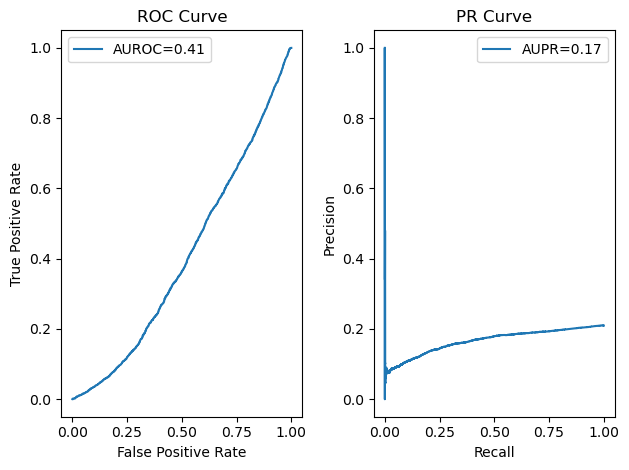

In [10]:
col = 'mean'
rep = 1

merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
merged = merged[merged['replicate']==rep]
merged['label'] = merged['label'].fillna(0)

auroc = metrics.roc_auc_score(merged['label'], merged[col])
aupr = metrics.average_precision_score(merged['label'], merged[col])
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUROC={auroc:.2f}")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr, label=f"AUPR={aupr:.2f}")
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()
plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/performance_roc_pr_curves_onsides.pdf')


In [11]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
len(neg), len(pos), neg.mean(), pos.mean()

(128527,
 34054,
 np.float64(0.10614418027005355),
 np.float64(0.07326360422156518))

In [12]:
merged['a'].min()

10